In [85]:
%run -i ../../python_scripts/nb_setup.py

#### Choose the dataset you want to use :
* must be data the model did not see at training
* first column : __y_true__ $\in \{0,1\}$ are the samples labels  
* second column : __y_pred__ are the predicted class of samples ($\in \{0,1\}$ too)
* third column : __kappa_f__ is confidence function for each sample, $\in \mathbb{R}$

In [86]:
sgp_df_SR = pickle.load(open("sgp_set_densenet_SR", "rb"))
print(
    "N =",
    sgp_df_SR.shape[0],
    "Proportion of 1s: ",
    np.round(sgp_df_SR.y_true.sum() / sgp_df_SR.shape[0], 2),
)
sgp_df_SR.head(3)

N = 23936 Proportion of 1s:  0.07


,y_true,y_pred,kappa
0,0.0,1.0,0.580018
1,0.0,0.0,0.939061
2,0.0,0.0,0.715950


In [87]:
num_targets = 5000  # number of targets r* to consider when drawing metric/coverage of metric/theta curves
theta_min_SR, theta_max_SR = 0.5, 1  # Sn-independent grids
metric_targets = np.linspace(0, 1, num=num_targets)

Plot lines configuration (cosmetic) 

In [88]:
lines_list_1_SR, lines_list_2_SR, _, _, _ = lines()

## 1. __Unconditional risks__

### 1.1. __0/1 risk__

In [89]:
train_set_SR, test_set_SR = train_test_split(
    sgp_df_SR, seed=0
)  # drawing 3/4 for bounds fitting, 1/4 for bounds testing
results_SR = sgp_at_targets(
    train_set_SR,
    test_set_SR,
    metric_targets=metric_targets,
    theta_min=theta_min_SR,
    theta_max=theta_max_SR,
)
all_results = {"SR": results_SR, "MCD": None}

Curves w.r.t. $\theta$, using Softmax Response (SR) as confidence function

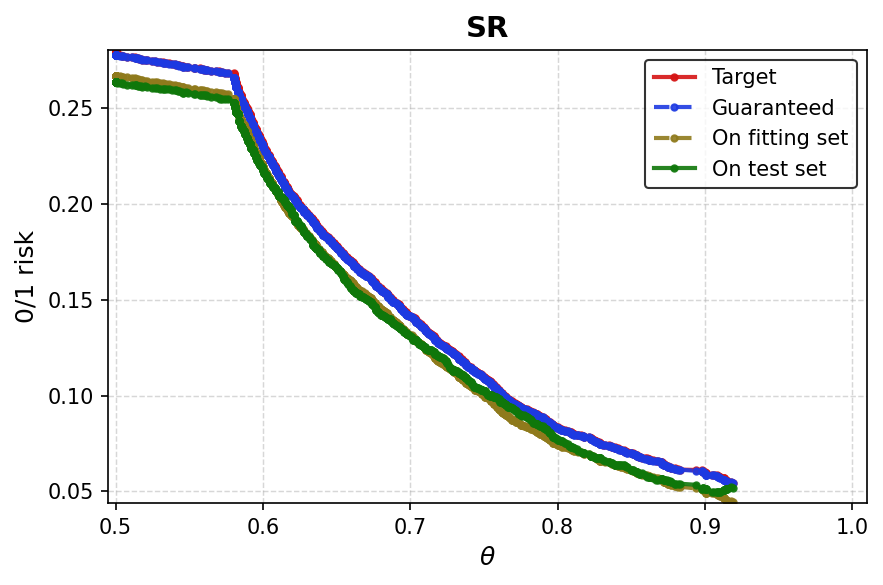

In [90]:
metric_plots(
    all_results,
    metric="0/1 risk",
    lines_list=lines_list_1_SR,
    xlim=[0.99 * theta_min_SR, 1.01 * theta_max_SR],
    ylim=[
        0.99 * min(min(results_SR.test_metric), min(results_SR.train_metric)),
        1.01 * max(results_SR.metric_bound),
    ],
    title="SR",
)

Curves w.r.t. coverage, using Softmax Response (SR) as confidence function

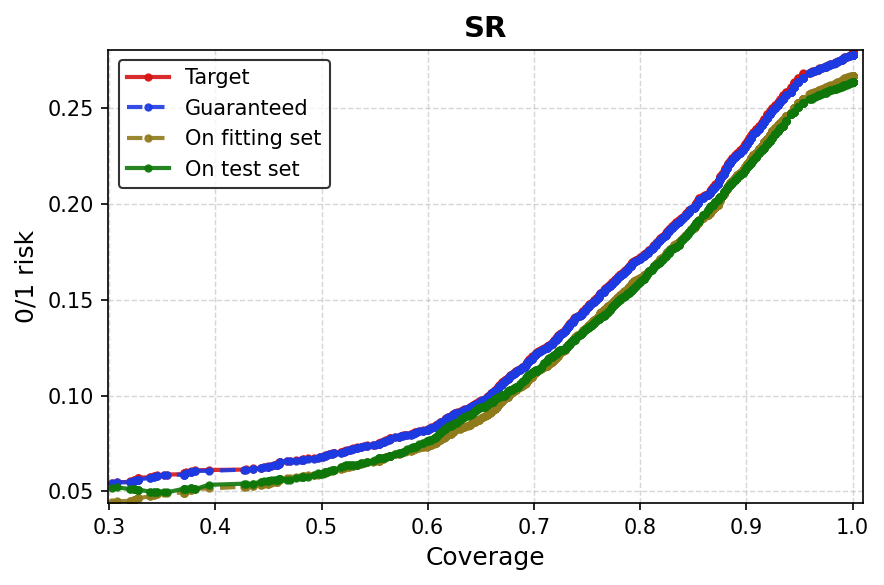

In [91]:
metric_plots(
    all_results,
    metric="0/1 risk",
    lines_list=lines_list_2_SR,
    xlim=[0.99 * min(results_SR.test_coverage), 1.01 * max(results_SR.test_coverage)],
    ylim=[
        0.99 * min(min(results_SR.test_metric), min(results_SR.train_metric)),
        1.01 * max(results_SR.metric_bound),
    ],
    title="SR",
)

### 1.2. __FP risk__

In [92]:
train_set_SR, test_set_SR = train_test_split(
    sgp_df_SR, seed=1
)  # drawing 3/4 for bounds fitting, 1/4 for bounds testing
results_SR = sgp_at_targets(
    train_set_SR,
    test_set_SR,
    metric_targets=metric_targets,
    metric="FP",
    theta_min=theta_min_SR,
    theta_max=theta_max_SR,
)
all_results = {"SR": results_SR, "MCD": None}

Curves w.r.t. $\theta$, using Softmax Response (SR) as confidence function

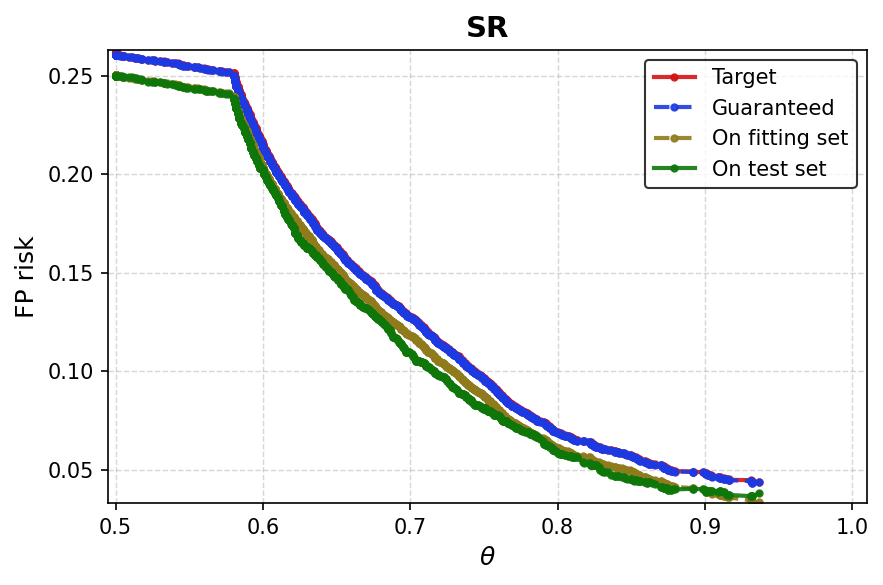

In [93]:
metric_plots(
    all_results,
    metric="FP risk",
    lines_list=lines_list_1_SR,
    xlim=[0.99 * theta_min_SR, 1.01 * theta_max_SR],
    ylim=[
        0.99 * min(min(results_SR.test_metric), min(results_SR.train_metric)),
        1.01 * max(results_SR.metric_bound),
    ],
    title="SR",
)

Curves w.r.t. coverage, using Softmax Response (SR) as confidence function

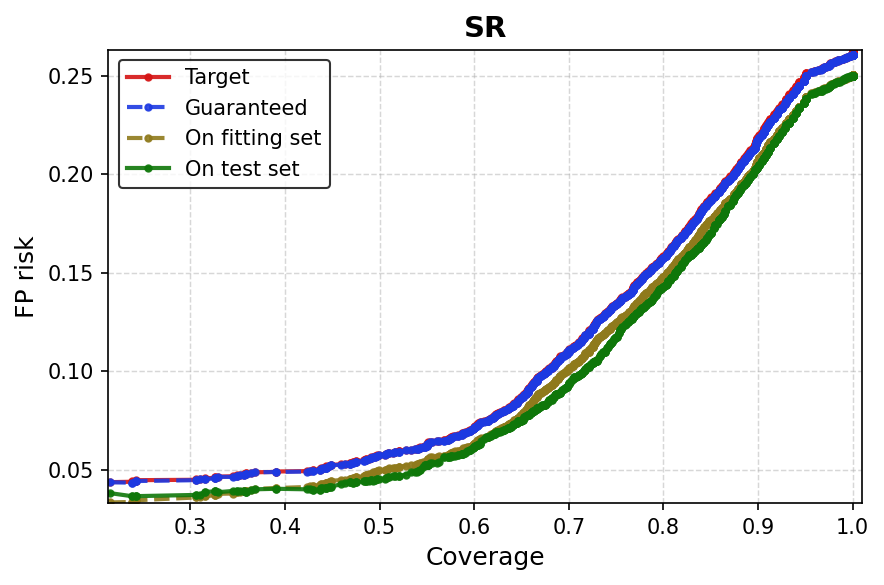

In [94]:
metric_plots(
    all_results,
    metric="FP risk",
    lines_list=lines_list_2_SR,
    xlim=[0.99 * min(results_SR.test_coverage), 1.01 * max(results_SR.test_coverage)],
    ylim=[
        0.99 * min(min(results_SR.test_metric), min(results_SR.train_metric)),
        1.01 * max(results_SR.metric_bound),
    ],
    title="SR",
)

### 1.3. __FN risk__

In [95]:
train_set_SR, test_set_SR = train_test_split(
    sgp_df_SR, seed=2
)  # drawing 3/4 for bounds fitting, 1/4 for bounds testing
results_SR = sgp_at_targets(
    train_set_SR,
    test_set_SR,
    metric_targets=metric_targets,
    metric="FN",
    theta_min=theta_min_SR,
    theta_max=theta_max_SR,
)
all_results = {"SR": results_SR, "MCD": None}

Curves w.r.t. $\theta$, using Softmax Response (SR) as confidence function

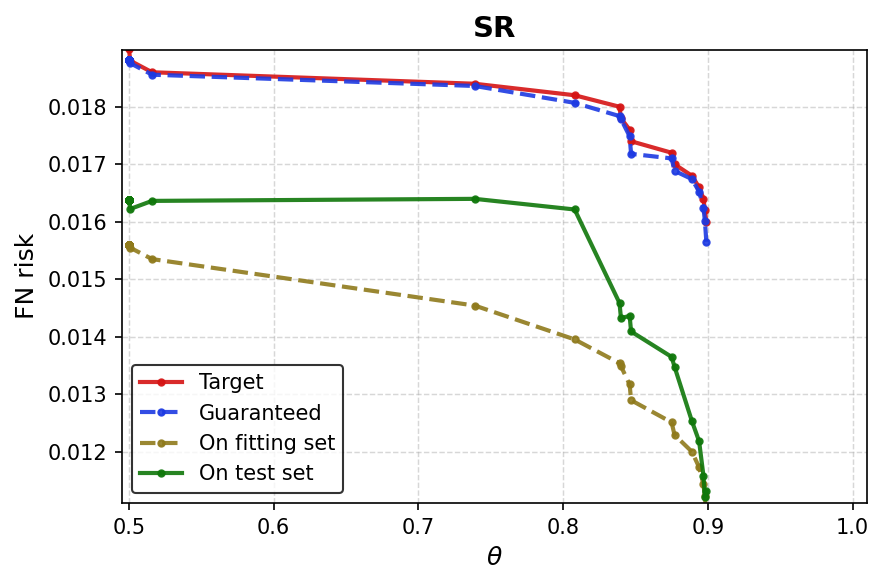

In [96]:
metric_plots(
    all_results,
    metric="FN risk",
    lines_list=lines_list_1_SR,
    xlim=[0.99 * theta_min_SR, 1.01 * theta_max_SR],
    ylim=[0.99 * min(results_SR.test_metric), 1.01 * max(results_SR.metric_bound)],
    title="SR",
)

Curves w.r.t. coverage, using Softmax Response (SR) as confidence function

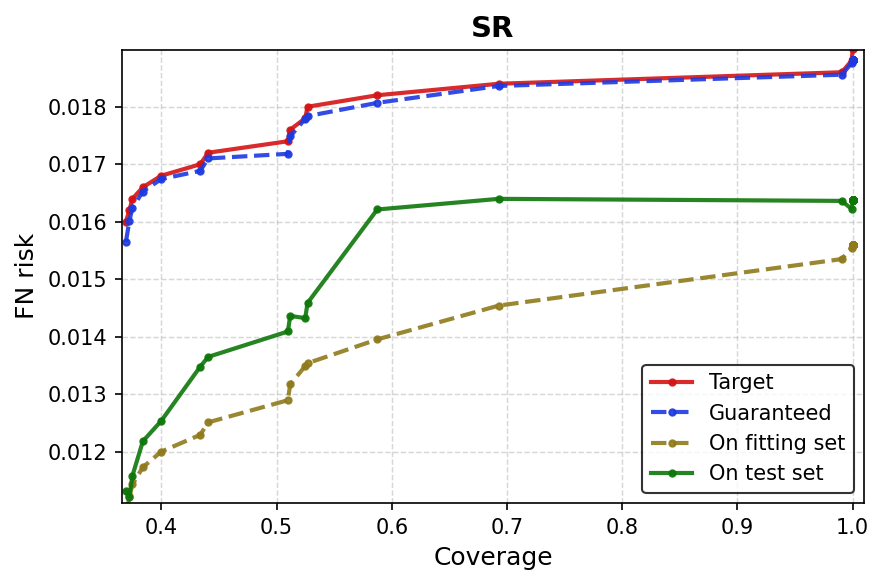

In [97]:
metric_plots(
    all_results,
    metric="FN risk",
    lines_list=lines_list_2_SR,
    xlim=[0.99 * min(results_SR.test_coverage), 1.01 * max(results_SR.test_coverage)],
    ylim=[0.99 * min(results_SR.test_metric), 1.01 * max(results_SR.metric_bound)],
    title="SR",
)

## __2. Conditional metrics__

### 2.1. __FPR__

In [98]:
train_set_SR, test_set_SR = train_test_split(
    sgp_df_SR, seed=3
)  # drawing 3/4 for bounds fitting, 1/4 for bounds testing
results_SR = sgp_at_targets(
    train_set_SR,
    test_set_SR,
    metric_targets=metric_targets,
    metric="FPR",
    theta_min=theta_min_SR,
    theta_max=theta_max_SR,
)
all_results = {"SR": results_SR, "MCD": None}

Curves w.r.t. $\theta$, using Softmax Response (SR) as confidence function

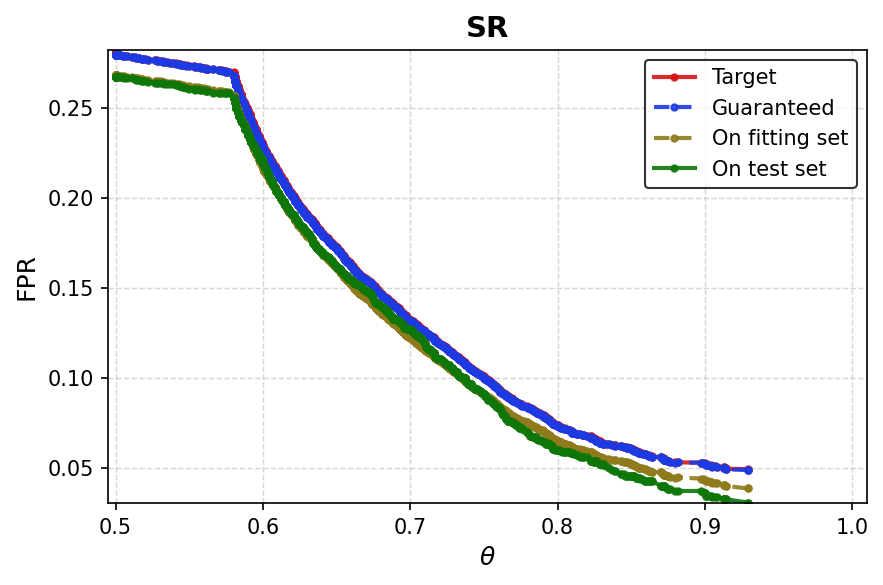

In [99]:
metric_plots(
    all_results,
    metric="FPR",
    lines_list=lines_list_1_SR,
    xlim=[0.99 * theta_min_SR, 1.01 * theta_max_SR],
    ylim=[0.99 * min(results_SR.test_metric), 1.01 * max(results_SR.metric_bound)],
    title="SR",
)

Curves w.r.t. coverage, using Softmax Response (SR) as confidence function

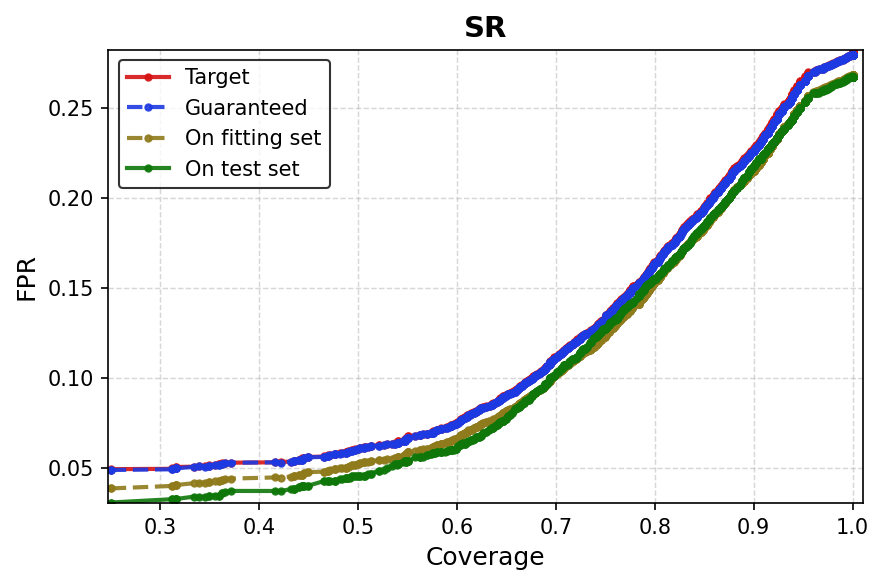

In [100]:
metric_plots(
    all_results,
    metric="FPR",
    lines_list=lines_list_2_SR,
    xlim=[0.99 * min(results_SR.test_coverage), 1.01 * max(results_SR.test_coverage)],
    ylim=[0.99 * min(results_SR.test_metric), 1.01 * max(results_SR.metric_bound)],
    title="SR",
)

### 2.2. __FNR__

In [101]:
train_set_SR, test_set_SR = train_test_split(
    sgp_df_SR, seed=4
)  # drawing 3/4 for bounds fitting, 1/4 for bounds testing
results_SR = sgp_at_targets(
    train_set_SR,
    test_set_SR,
    metric_targets=metric_targets,
    metric="FNR",
    theta_min=theta_min_SR,
    theta_max=theta_max_SR,
)
all_results = {"SR": results_SR, "MCD": None}

Curves w.r.t. $\theta$, using Softmax Response (SR) as confidence function

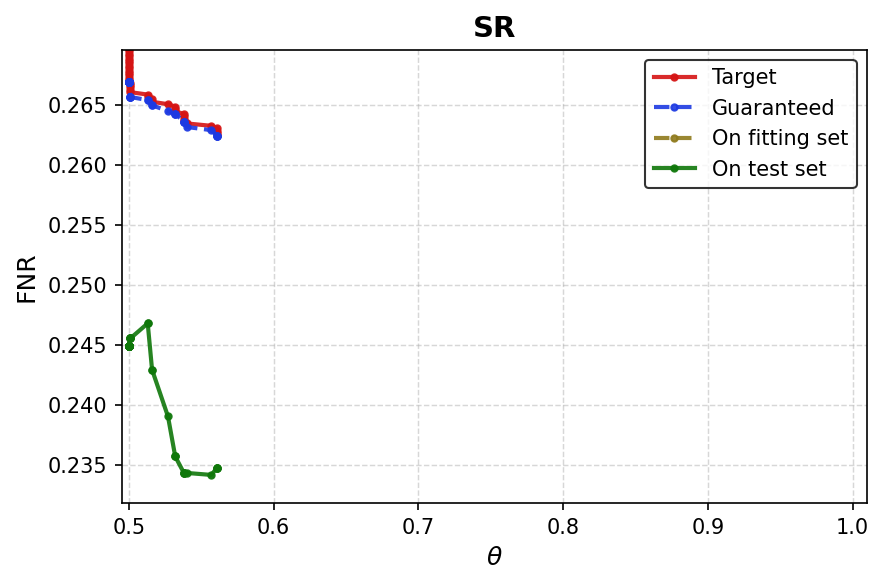

In [102]:
metric_plots(
    all_results,
    metric="FNR",
    lines_list=lines_list_1_SR,
    xlim=[0.99 * theta_min_SR, 1.01 * theta_max_SR],
    ylim=[0.99 * min(results_SR.test_metric), 1.01 * max(results_SR.metric_bound)],
    title="SR",
)

Curves w.r.t. coverage, using Softmax Response (SR) as confidence function

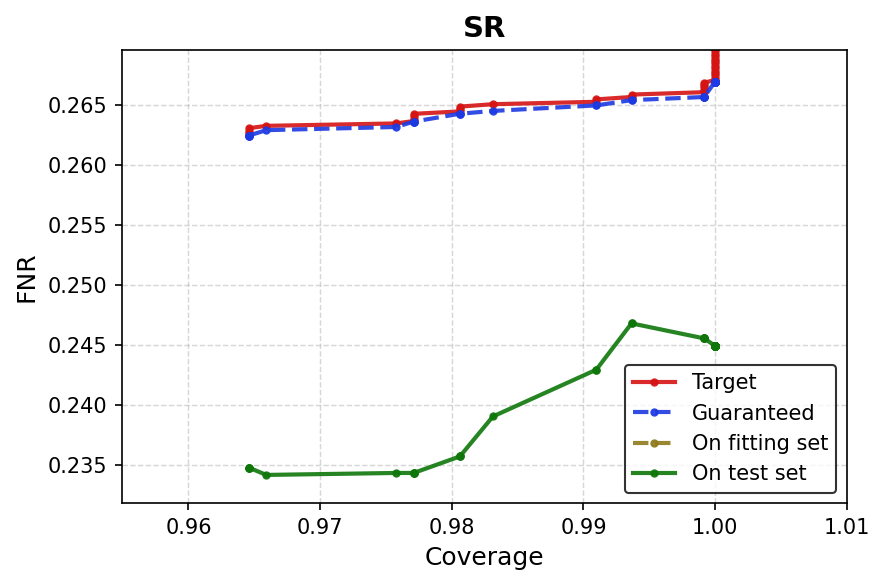

In [103]:
metric_plots(
    all_results,
    metric="FNR",
    lines_list=lines_list_2_SR,
    xlim=[0.99 * min(results_SR.test_coverage), 1.01 * max(results_SR.test_coverage)],
    ylim=[0.99 * min(results_SR.test_metric), 1.01 * max(results_SR.metric_bound)],
    title="SR",
)

### 2.3. __PPV__

In [104]:
train_set_SR, test_set_SR = train_test_split(
    sgp_df_SR, seed=5
)  # drawing 3/4 for bounds fitting, 1/4 for bounds testing
results_SR = sgp_at_targets(
    train_set_SR,
    test_set_SR,
    metric_targets=metric_targets,
    metric="PPV",
    theta_min=theta_min_SR,
    theta_max=theta_max_SR,
)
all_results = {"SR": results_SR, "MCD": None}

Curves w.r.t. $\theta$, using Softmax Response (SR) as confidence function

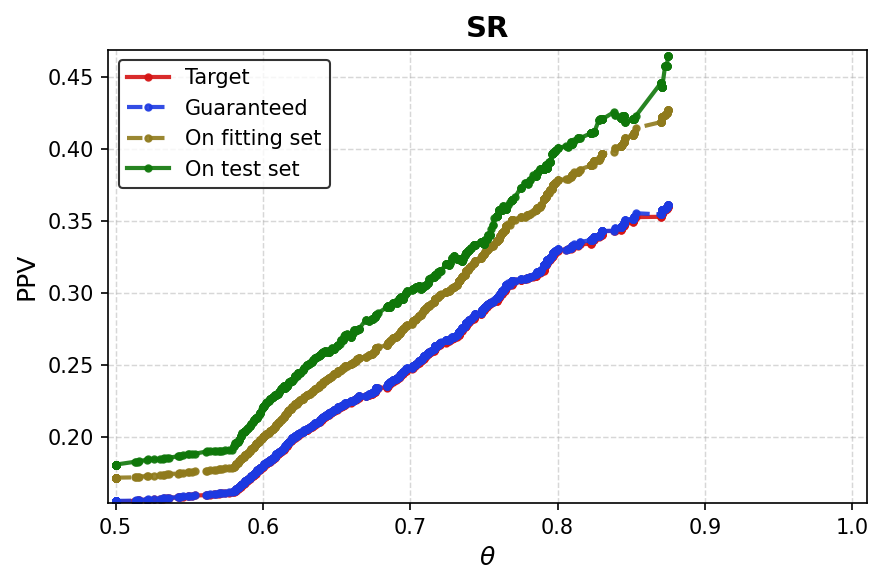

In [105]:
metric_plots(
    all_results,
    metric="PPV",
    lines_list=lines_list_1_SR,
    xlim=[0.99 * theta_min_SR, 1.01 * theta_max_SR],
    ylim=[
        0.99 * min(results_SR.metric_bound),
        min(1, 1.01 * max(max(results_SR.test_metric), max(results_SR.train_metric))),
    ],
    title="SR",
)

Curves w.r.t. coverage, using Softmax Response (SR) as confidence function

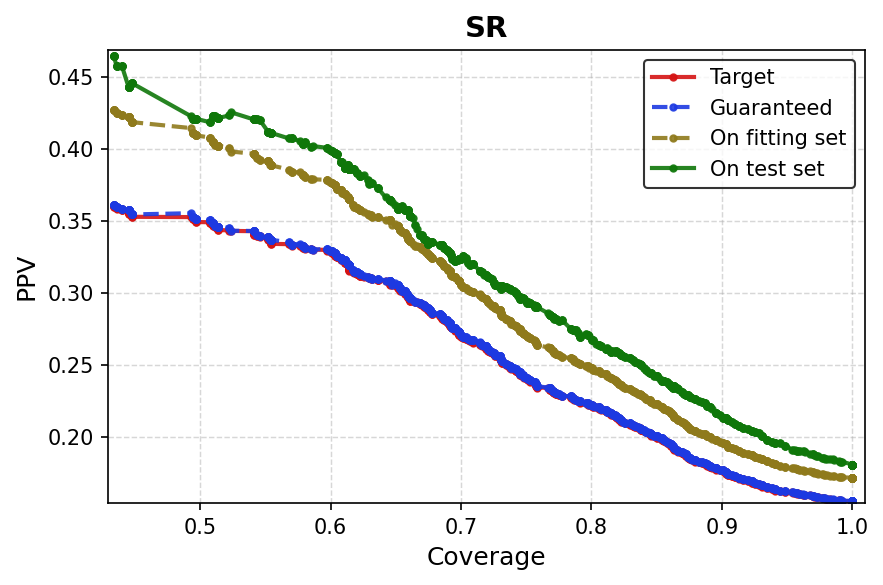

In [106]:
metric_plots(
    all_results,
    metric="PPV",
    lines_list=lines_list_2_SR,
    xlim=[0.99 * min(results_SR.test_coverage), 1.01 * max(results_SR.test_coverage)],
    ylim=[
        0.99 * min(results_SR.metric_bound),
        min(1, 1.01 * max(max(results_SR.test_metric), max(results_SR.train_metric))),
    ],
    title="SR",
)

### 2.4. __SE__

In [107]:
train_set_SR, test_set_SR = train_test_split(
    sgp_df_SR, seed=6
)  # drawing 3/4 for bounds fitting, 1/4 for bounds testing
results_SR = sgp_at_targets(
    train_set_SR,
    test_set_SR,
    metric_targets=metric_targets,
    metric="SE",
    theta_min=theta_min_SR,
    theta_max=theta_max_SR,
)
all_results = {"SR": results_SR, "MCD": None}

Curves w.r.t. $\theta$, using Softmax Response (SR) as confidence function

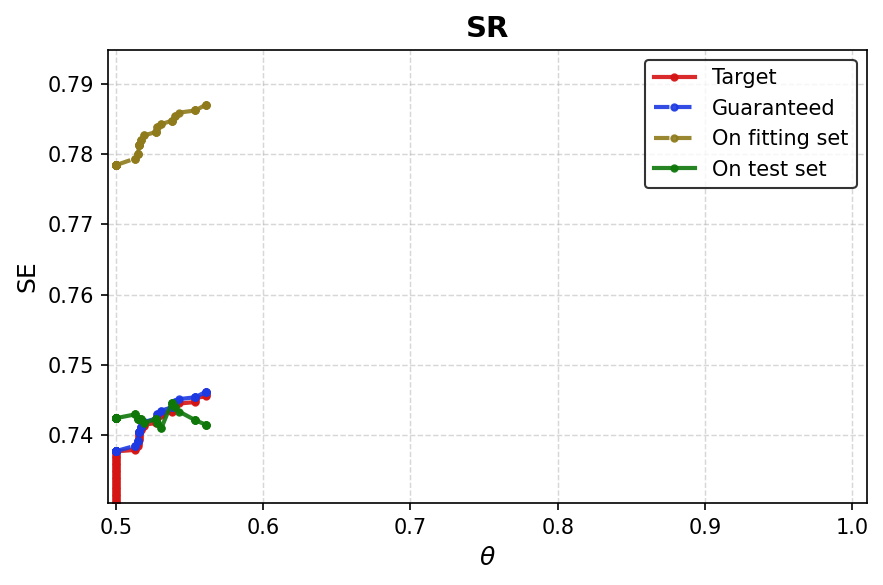

In [108]:
metric_plots(
    all_results,
    metric="SE",
    lines_list=lines_list_1_SR,
    xlim=[0.99 * theta_min_SR, 1.01 * theta_max_SR],
    ylim=[
        0.99 * min(results_SR.metric_bound),
        min(1, 1.01 * max(max(results_SR.test_metric), max(results_SR.train_metric))),
    ],
    title="SR",
)

Curves w.r.t. coverage, using Softmax Response (SR) as confidence function

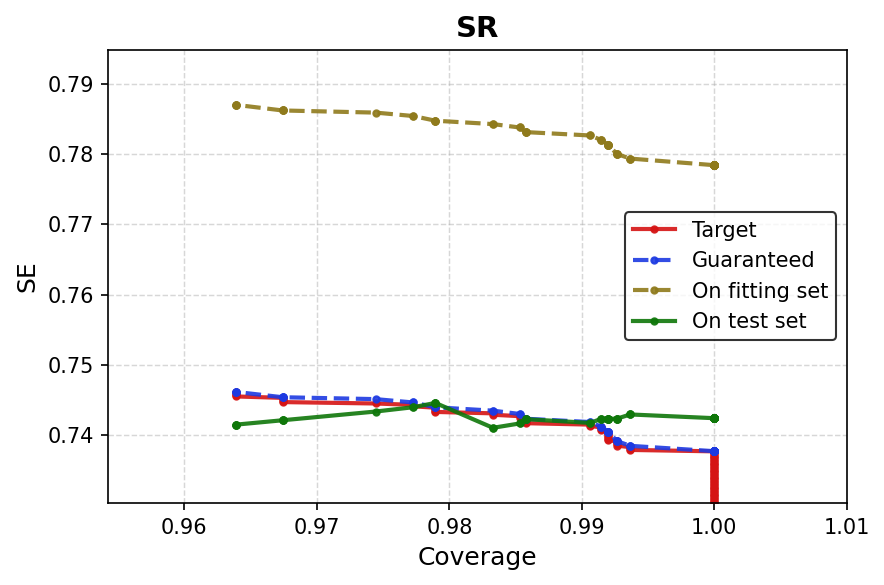

In [109]:
metric_plots(
    all_results,
    metric="SE",
    lines_list=lines_list_2_SR,
    xlim=[0.99 * min(results_SR.test_coverage), 1.01 * max(results_SR.test_coverage)],
    ylim=[
        0.99 * min(results_SR.metric_bound),
        min(1, 1.01 * max(max(results_SR.test_metric), max(results_SR.train_metric))),
    ],
    title="SR",
)

### 2.5. __SP__

In [110]:
train_set_SR, test_set_SR = train_test_split(
    sgp_df_SR, seed=7
)  # drawing 3/4 for bounds fitting, 1/4 for bounds testing
results_SR = sgp_at_targets(
    train_set_SR,
    test_set_SR,
    metric_targets=metric_targets,
    metric="SP",
    theta_min=theta_min_SR,
    theta_max=theta_max_SR,
)
all_results = {"SR": results_SR, "MCD": None}

Curves w.r.t. $\theta$, using Softmax Response (SR) as confidence function

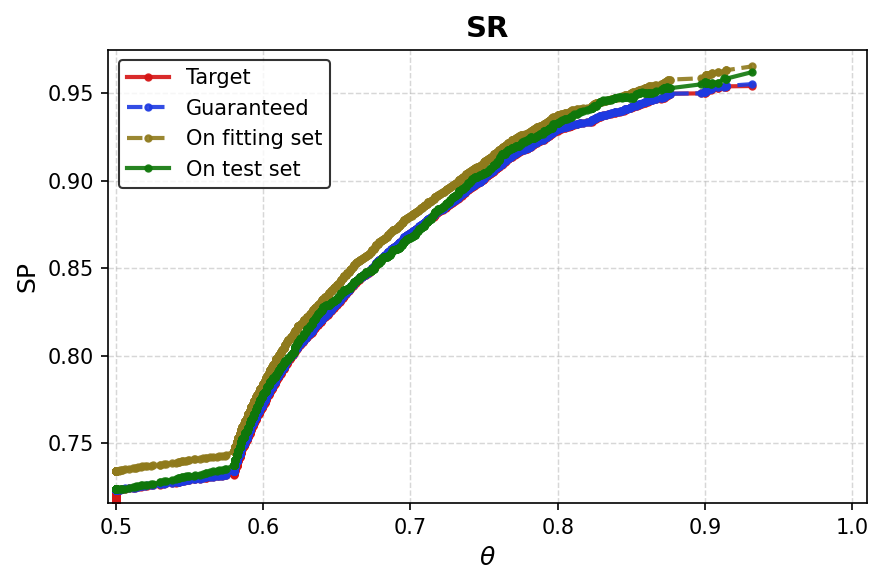

In [111]:
metric_plots(
    all_results,
    metric="SP",
    lines_list=lines_list_1_SR,
    xlim=[0.99 * theta_min_SR, 1.01 * theta_max_SR],
    ylim=[
        0.99 * min(results_SR.metric_bound),
        min(1, 1.01 * max(max(results_SR.test_metric), max(results_SR.train_metric))),
    ],
    title="SR",
)

Curves w.r.t. coverage, using Softmax Response (SR) as confidence function

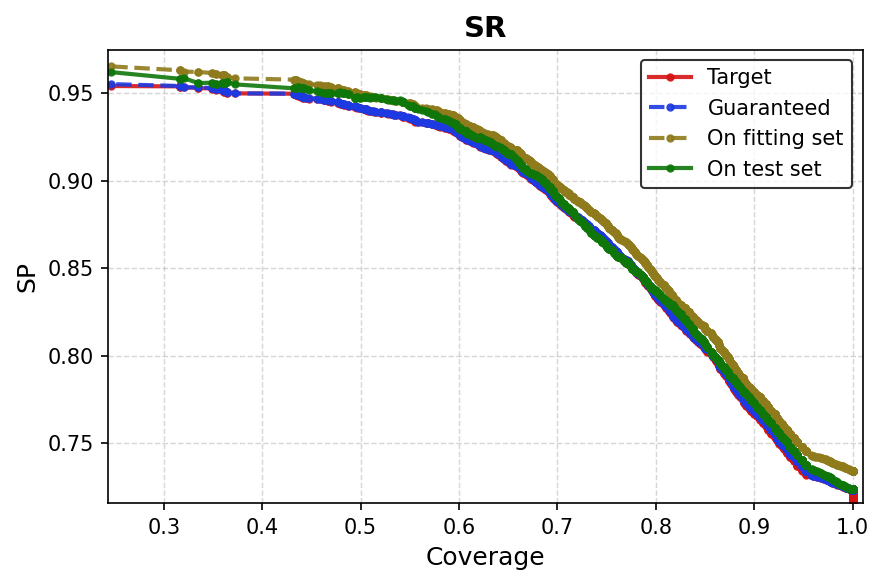

In [112]:
metric_plots(
    all_results,
    metric="SP",
    lines_list=lines_list_2_SR,
    xlim=[0.99 * min(results_SR.test_coverage), 1.01 * max(results_SR.test_coverage)],
    ylim=[
        0.99 * min(results_SR.metric_bound),
        min(1, 1.01 * max(max(results_SR.test_metric), max(results_SR.train_metric))),
    ],
    title="SR",
)